Loaded 11 documents.
{'text': 'First document. Second sentence. New topic starts here. Another sentence.', 'boundaries': [1, 2, 3]}
First document. Second sentence. New topic starts here. Another sentence.
[1, 2, 3]
Epoch 1/5
Train Loss: 2.0871
Val Loss: 0.5449 
Epoch 2/5
Train Loss: 1.5339
Val Loss: 0.5506 
Epoch 3/5
Train Loss: 1.2361
Val Loss: 0.5688 
Epoch 4/5
Train Loss: 1.1901
Val Loss: 0.5515 
Epoch 5/5
Train Loss: 1.1026
Val Loss: 0.5603 


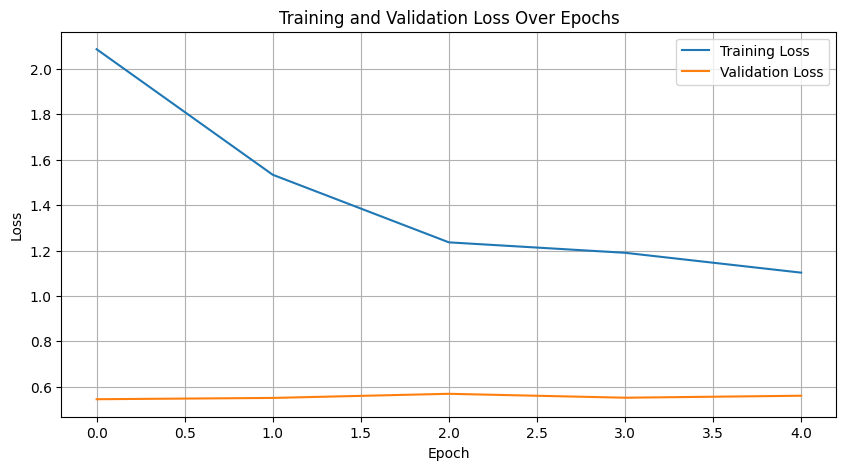

In [ ]:
import torch
import nltk
from transformers import LongformerModel, LongformerConfig, AutoTokenizer
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import random
from nltk.tokenize import PunktSentenceTokenizer
from sklearn.metrics import f1_score
import numpy as np
import os
from transformers import logging
import pandas as pd
import ast
import torch.nn.functional as F
import torch.nn as nn

# Initialize shared tokenizer
shared_tokenizer = AutoTokenizer.from_pretrained('allenai/longformer-base-4096', add_prefix_space=True)
shared_tokenizer.add_special_tokens({'bos_token': '[BOS]'})

# Suppress warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
logging.set_verbosity_error()

# Download NLTK punkt tokenizer if not present
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)

# ====================== 1. Data Preprocessing ======================
class WikiPreprocessor:
    def __init__(self):
        self.sent_tokenizer = PunktSentenceTokenizer()
        self.tokenizer = shared_tokenizer

    def process_document(self, text):
        try:
            sentences = self.sent_tokenizer.tokenize(text)
            return [f"[BOS]{' ' + sent.strip() if sent.strip() else ''}" for sent in sentences]
        except Exception as e:
            print(f"Error processing document: {e}")
            return ["[BOS] Invalid document"]

    def create_labels(self, boundaries, num_sentences):
        labels = [0] * num_sentences
        for idx in boundaries:
            if idx < num_sentences:
                labels[idx] = 1
        return labels

# ====================== 2. Model Architecture ======================
class TopicSegmenter(torch.nn.Module):
    def __init__(self, model_name='allenai/longformer-base-4096', dropout=0.1):
        super().__init__()
        self.tokenizer = shared_tokenizer
        self.config = LongformerConfig.from_pretrained(model_name)
        
        # Initialize model components
        self.encoder = LongformerModel.from_pretrained(model_name, config=self.config)
        self.encoder.resize_token_embeddings(len(self.tokenizer))
        
        self.dropout = torch.nn.Dropout(dropout)
        self.classifier = torch.nn.Linear(self.config.hidden_size, 2)
        self.projection = torch.nn.Linear(self.config.hidden_size, 256)
        
        # Additional layer for attention scores
        self.attention_proj = torch.nn.Linear(self.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask, global_attention_mask=None):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            global_attention_mask=global_attention_mask
        )

        # Get BOS representations
        bos_positions = (input_ids == self.tokenizer.bos_token_id).nonzero(as_tuple=True)
        
        if bos_positions[0].numel() == 0:
            seq_len = input_ids.shape[0]
            dummy = torch.zeros((seq_len, self.config.hidden_size), device=input_ids.device)
            dummy_attn = torch.zeros((seq_len, seq_len), device=input_ids.device)
            return dummy, dummy_attn, dummy  # projections, attention_scores, logits

        bos_embeddings = outputs.last_hidden_state[bos_positions]
        
        # Compute attention scores (dot-product with projection)
        attention_scores = bos_embeddings @ bos_embeddings.T
        
        # Project embeddings for partial order loss
        projections = self.projection(bos_embeddings)
        
        # Classification head
        logits = self.classifier(self.dropout(bos_embeddings))
        
        return projections, attention_scores, logits

# ====================== 3. Loss Functions ======================
class CalibrationLoss:
    def __init__(self, temperature=0.1):
        self.temperature = temperature
        self.eps = 1e-8

    def __call__(self, attention_scores, delta_mask):
        alpha = torch.softmax(attention_scores / self.temperature, dim=-1)
        same_topic_attn = alpha * delta_mask
        denom = torch.sum(same_topic_attn, dim=-1, keepdim=True) + self.eps
        print(f"Alpha: {alpha}")
        print(f"Denom: {denom}")
        log_terms = torch.log(alpha / denom) * delta_mask
        print(f"Log Terms: {log_terms}")
        return -torch.sum(log_terms) / (torch.sum(delta_mask) + self.eps)

    @staticmethod
    def create_delta_mask(boundaries, num_sentences, device='cpu'):
        mask = torch.zeros((num_sentences, num_sentences), device=device)
        segments = []
        start = 0
        for end in boundaries:
            segments.append((start, end))
            start = end + 1
        segments.append((start, num_sentences-1))
        
        for (s1, e1) in segments:
            for i in range(s1, e1+1):
                for j in range(s1, e1+1):
                    mask[i,j] = 1
        return mask

class PartialOrderLoss:
    def __init__(self, rho=0.3, m1=0.5, m2=0.8):
        self.rho = rho
        self.m1 = m1
        self.m2 = m2
        self.cos = nn.CosineSimilarity(dim=-1)

    def __call__(self, projections, boundaries):
        losses = []
        topics = self._split_into_topics(projections, boundaries)

        topic_indices = []
        current_global = 0
        for topic in topics:
            topic_indices.append((current_global, current_global + len(topic)))
            current_global += len(topic)

        for global_idx in range(len(projections)):
            topic_idx = self._find_topic(global_idx, topic_indices)
            current_topic = topics[topic_idx]
            local_idx = global_idx - topic_indices[topic_idx][0]

            anchor = current_topic[local_idx].unsqueeze(0)

            if local_idx + 1 < len(current_topic):
                positive = current_topic[local_idx + 1].unsqueeze(0)
            else:
                continue

            partial_candidates = [sent for i, topic in enumerate(topics) 
                               if i != topic_idx for sent in topic]
            if not partial_candidates:
                continue
            partial = random.choice(partial_candidates).unsqueeze(0)
            negative = random.choice(partial_candidates).unsqueeze(0)

            d_ap = 1 - self.cos(anchor, positive)
            d_aq = 1 - self.cos(anchor, partial)
            d_an = 1 - self.cos(anchor, negative)

            loss_pos = F.relu(d_ap - self.rho)
            loss_partial = F.relu(self.m1 - d_aq) + F.relu(d_aq - self.m2)
            loss_neg = F.relu(self.m2 - d_an)

            losses.append(loss_pos + loss_partial + loss_neg)

        return torch.mean(torch.stack(losses)) if losses else torch.tensor(0.0)

    def _split_into_topics(self, projections, boundaries):
        topics = []
        start = 0
        for end in boundaries:
            topics.append(projections[start:end+1])
            start = end + 1
        if start < len(projections):
            topics.append(projections[start:])
        return topics

    def _find_topic(self, global_idx, topic_indices):
        for i, (start, end) in enumerate(topic_indices):
            if start <= global_idx < end:
                return i
        return len(topic_indices) - 1
    
class HardNegativeMiningLoss:
    def __init__(self, margin=0.5):
        self.margin = margin
        self.cos = nn.CosineSimilarity(dim=-1)
        
    def __call__(self, projections, boundaries):
        """
        projections: [num_sentences, dim]
        boundaries: list of boundary indices
        """
        losses = []
        topics = self._split_into_topics(projections, boundaries)
        
        # Precompute all pairwise distances
        sim_matrix = projections @ projections.T  # [N, N] similarity matrix
        
        for i in range(len(projections)):
            # Find which topic this sentence belongs to
            topic_idx = self._find_topic(i, topics)
            current_topic = topics[topic_idx]
            
            # Positive: next sentence in same topic
            if i + 1 < len(projections) and self._find_topic(i+1, topics) == topic_idx:
                positive = projections[i+1]
            else:
                continue
                
            # Hard negative: most similar sentence from different topic
            # Mask to exclude same-topic sentences
            mask = torch.ones(len(projections), dtype=torch.bool, device=projections.device)
            for j in range(len(projections)):
                if self._find_topic(j, topics) == topic_idx:
                    mask[j] = False
                    
            if not mask.any():
                continue
                
            # Get similarity scores with different-topic sentences
            diff_topic_sim = sim_matrix[i] * mask.float()
            hard_negative_idx = diff_topic_sim.argmax()
            hard_negative = projections[hard_negative_idx]
            
            # Compute triplet loss
            d_ap = 1 - self.cos(projections[i].unsqueeze(0), positive.unsqueeze(0))
            d_an = 1 - self.cos(projections[i].unsqueeze(0), hard_negative.unsqueeze(0))
            losses.append(F.relu(d_ap - d_an + self.margin))
            
        return torch.mean(torch.stack(losses)) if losses else torch.tensor(0.0)
    
    def _split_into_topics(self, projections, boundaries):
        topics = []
        start = 0
        for end in boundaries:
            topics.append(projections[start:end+1])
            start = end + 1
        if start < len(projections):
            topics.append(projections[start:])
        return topics
        
    def _find_topic(self, idx, topics):
        current = 0
        for i, topic in enumerate(topics):
            if idx < current + len(topic):
                return i
            current += len(topic)
        return len(topics) - 1


class CombinedLoss:
    def __init__(self, alpha=1.0, beta=1.0, gamma=1.0, 
                 cal_temp=0.1, po_rho=0.3, po_m1=0.5, po_m2=0.8, hn_margin=0.5):
        self.alpha = alpha  # Calibration loss weight
        self.beta = beta    # Partial order loss weight
        self.gamma = gamma  # Hard negative loss weight
        
        self.cal_loss = CalibrationLoss(temperature=cal_temp)
        self.po_loss = PartialOrderLoss(rho=po_rho, m1=po_m1, m2=po_m2)
        self.hn_loss = HardNegativeMiningLoss(margin=hn_margin)

    def __call__(self, projections, attention_scores, boundaries):
        delta_mask = CalibrationLoss.create_delta_mask(
            boundaries, len(projections), device=projections.device)
        
        # cal_loss = self.cal_loss(attention_scores, delta_mask)
        cal_loss = self.cal_loss(attention_scores, delta_mask)
        po_loss = self.po_loss(projections, boundaries)
        hn_loss = self.hn_loss(projections, boundaries)
        
        # print(f"PO Loss: {po_loss.item():.4f} | HN Loss: {hn_loss.item():.4f}")
        
        return (self.alpha * cal_loss + 
                self.beta * po_loss + 
                self.gamma * hn_loss)

# ====================== 4. Training Setup ======================
class TopicDataset(Dataset):
    def __init__(self, documents, tokenizer, max_len=4096):
        self.documents = documents
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.preprocessor = WikiPreprocessor()

    def __len__(self):
        return len(self.documents)

    def __getitem__(self, idx):
        doc = self.documents[idx]['text'].strip()
        boundaries = self.documents[idx]['boundaries']

        processed = self.preprocessor.process_document(doc)
        if not processed or all(not sent.strip() for sent in processed):
            processed = ["[BOS] Empty document"]

        labels = self.preprocessor.create_labels(boundaries, len(processed))

        encoding = self.tokenizer(
            processed,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
            is_split_into_words=True,
            add_special_tokens=True
        )

        bos_positions = (encoding['input_ids'] == self.tokenizer.bos_token_id)
        global_attention = torch.zeros_like(encoding['input_ids'])
        global_attention[bos_positions] = 1

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'global_attention_mask': global_attention.squeeze(0),
            'labels': torch.tensor(labels, dtype=torch.long)
        }

class Trainer:
    def __init__(self, model, train_loader, val_loader, args):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.args = args
        self.optim = AdamW(model.parameters(), lr=args['lr'])
        self.ce_loss = nn.CrossEntropyLoss()
        self.combined_loss = CombinedLoss(
            alpha=args['alpha'],
            beta=args['beta'],
            cal_temp=args.get('cal_temp', 0.1),
            po_rho=args.get('po_rho', 0.3),
            po_m1=args.get('po_m1', 0.5),
            po_m2=args.get('po_m2', 0.8)
        )

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for batch in self.train_loader:
            if batch['input_ids'].numel() == 0:
                continue

            self.optim.zero_grad()

            input_ids = batch['input_ids'].to(self.args['device'])
            attention_mask = batch['attention_mask'].to(self.args['device'])
            global_attention_mask = batch['global_attention_mask'].to(self.args['device'])
            labels = batch['labels'].to(self.args['device'])

            projections, attention_scores, logits = self.model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                global_attention_mask=global_attention_mask
            )

            bos_positions = (input_ids == self.model.tokenizer.bos_token_id)
            valid_labels = labels.view(-1)
            
            ce_loss = self.ce_loss(logits, valid_labels)
            
            boundaries = (valid_labels == 1).nonzero(as_tuple=True)[0].cpu().tolist()
            comb_loss = self.combined_loss(projections, attention_scores, boundaries)
            
            loss = ce_loss + comb_loss
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optim.step()

            total_loss += loss.item()

        return total_loss / len(self.train_loader)

    def evaluate(self):
        self.model.eval()
        total_loss = 0.0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for batch in self.val_loader:
                input_ids = batch['input_ids'].to(self.args['device'])
                attention_mask = batch['attention_mask'].to(self.args['device'])
                global_attention_mask = batch['global_attention_mask'].to(self.args['device'])
                labels = batch['labels'].to(self.args['device'])

                _, _, logits = self.model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    global_attention_mask=global_attention_mask
                )

                valid_labels = labels.view(-1)
                loss = self.ce_loss(logits, valid_labels)
                total_loss += loss.item()

                preds = torch.argmax(logits, dim=-1)
                all_preds.append(preds.cpu().numpy())
                all_labels.append(labels.cpu().numpy().flatten())

        all_preds = np.concatenate(all_preds, axis=0)
        all_labels = np.concatenate(all_labels, axis=0)
        f1 = f1_score(all_labels, all_preds)
        
        return {
            'loss': total_loss / len(self.val_loader),
            'f1': f1
        }

# ====================== 5. Utility Functions ======================
def load_dataset_from_csv(csv_path):
    df = pd.read_csv(csv_path)
    dataset = []
    for _, row in df.iterrows():
        text = row['text']
        boundaries = ast.literal_eval(row['boundaries']) if isinstance(row['boundaries'], str) else row['boundaries']
        dataset.append({'text': text, 'boundaries': boundaries})
    return dataset

# ====================== 7. Results Generation ======================
def generate_results(model, data_loader, device, model_name="Combined Loss Model"):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            global_attention_mask = batch['global_attention_mask'].to(device)
            labels = batch['labels'].to(device)

            _, _, logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                global_attention_mask=global_attention_mask
            )

            preds = torch.argmax(logits, dim=-1)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy().flatten())
    
    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    
    # Calculate metrics
    accuracy = (all_preds == all_labels).mean()
    f1 = f1_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    
    # Print results
    print(f"\n=== {model_name} Results ===")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No Boundary', 'Boundary'],
                yticklabels=['No Boundary', 'Boundary'])
    plt.title(f'{model_name} Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'confusion_matrix': cm
    }



# ====================== 6. Main Execution ======================
if __name__ == "__main__":
    # Configuration
    config = {
        'model_name': 'allenai/longformer-base-4096',
        'batch_size': 4,
        'max_seq_len': 4096,
        'lr': 5e-5,
        'epochs': 5,
        'alpha': 0,  # Calibration loss weight
        'beta': 0.9,   # Partial order loss weight
        'gamma': 0.1,
        'cal_temp': 0.1,
        'po_rho': 0.3,
        'po_m1': 0.5,
        'po_m2': 0.8,
        'device': 'cuda' if torch.cuda.is_available() else 'cpu'
        # 'device': 'cpu'
    }

    # Load data
    csv_path = '/home/om/text_seg_oml/text_seg/topic_dataset.csv'
    documents = load_dataset_from_csv(csv_path)
    
    print(f"Loaded {len(documents)} documents.")
    print(documents[0])
    print(documents[0]['text']) 
    print(documents[0]['boundaries'])
    # Split data
    train_size = max(1, int(0.8 * len(documents)))
    train_data = documents[:train_size]
    val_data = documents[train_size:]

    # Create datasets and dataloaders
    train_dataset = TopicDataset(train_data, shared_tokenizer, config['max_seq_len'])
    val_dataset = TopicDataset(val_data, shared_tokenizer, config['max_seq_len'])
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'])

    # Initialize model and trainer
    model = TopicSegmenter(config['model_name']).to(config['device'])
    trainer = Trainer(model, train_loader, val_loader, config)

    import matplotlib.pyplot as plt

    train_losses = []
    val_losses = []

    # Training loop
    for epoch in range(config['epochs']):
        train_loss = trainer.train_epoch()
        val_metrics = trainer.evaluate()

        print(f"Epoch {epoch+1}/{config['epochs']}")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val Loss: {val_metrics['loss']:.4f} ")
        train_losses.append(train_loss)
        val_losses.append(val_metrics['loss'])
    plt.figure(figsize=(10, 5))
    
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

